In [1]:
import os,sys
import numpy as np
import pandas as pd
root = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.append(root)
from utils import utils,models

In [2]:
device = utils.get_device()
print(f"Using device: {device}")
batch_size = 8

Using device: mps


In [ ]:
model_name = 'ViT-L/14'
model, preprocess = utils.load_model(model_name, device)
dataset_dir = '../dataset/newsimages_test_and_evaluation_26_v1.0'
images_dir = f'{dataset_dir}/news_images_evaluation'
dataset = pd.read_csv(f"../dataset/evaluation_with_captions.csv",encoding="latin-1")
dataset.set_index('article_id', inplace=True)
dataset['article_title'] = dataset['article_title'].apply(utils.normalize_text)
records = [
    {
        "image_path": utils.make_path(images_dir, row['image_id']),
        "title": row['article_title'],
        "caption": str(row['caption']) if pd.notna(row['caption']) else ""
    }
    for _, row in dataset.iterrows()

]
captions = [r["caption"].strip() for r in records]
image_paths = [r["image_path"] for r in records]
model_path = f"../artifacts/{model_name.replace('/','-')}_embeddings_evaluation_images.npy"
if os.path.exists(model_path):
    print("Using cached image embeddings")
    image_embeddings = np.load(model_path)
else:
    image_embeddings = utils.encode_images(image_paths, model, preprocess, batch_size, device)
    np.save(model_path, image_embeddings)

Using cached embeddings


In [7]:
captions_embeddings_path = f"../artifacts/{model_name.replace('/','-')}_embeddings_evaluation_captions.npy"
if os.path.exists(captions_embeddings_path):
    print("Using cached captions embeddings")
    caption_embeddings = np.load(captions_embeddings_path)
else:
    caption_embeddings = utils.encode_texts(captions, model, device)
    np.save(captions_embeddings_path,caption_embeddings)

Using cached captions embeddings


In [8]:
id_to_index = utils.build_id_to_index(image_paths)
article_titles,ground_truth = utils.build_ground_truth(dataset,images_dir,id_to_index)
data = [(q, img_id[0]) for q, img_id in ground_truth.items()]

In [6]:
generator = models.OllamaPipeline()

In [7]:
combined_clip = models.QECaptionRerankRetrieval(model,image_embeddings,caption_embeddings,generator,device,"../dataset/q-title-to-expanded-mapping.json")
mrr = utils.compute_mrr(combined_clip,data,10)
queries = list(ground_truth.keys())
recalls = utils.evaluate(combined_clip,queries,ground_truth)

In [8]:
mrr

np.float64(0.34005974863977695)

In [9]:
# 0.5 alpha
# {1: np.float64(0.19036827195467423),
#  5: np.float64(0.38923512747875355),
#  10: np.float64(0.48541076487252127)}
# mrr - np.float64(0.27587582625118034)

# 0.9 alpha
# {1: np.float64(0.19242209631728047),
#  5: np.float64(0.3946175637393768),
#  10: np.float64(0.4935552407932011)}
# mrr - np.float64(0.27930743850892575)

# 0.8 alpha
# {1: np.float64(0.19355524079320113),
#  5: np.float64(0.39575070821529745),
#  10: np.float64(0.4934135977337111)}
# mrr - np.float64(0.2806887955843338)
recalls

{1: np.float64(0.24327195467422097),
 5: np.float64(0.4681303116147309),
 10: np.float64(0.5712464589235128)}

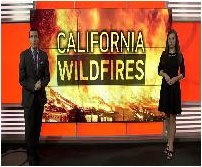

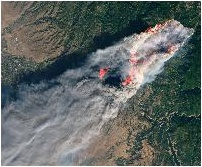

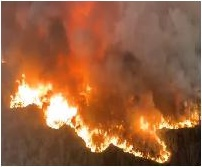

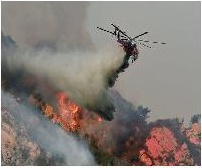

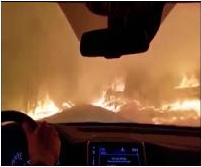

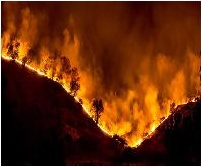

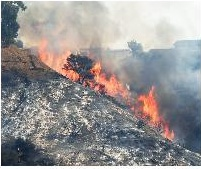

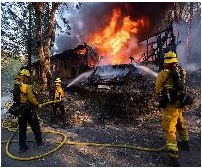

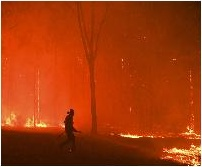

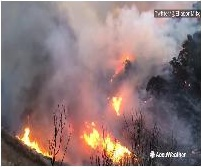

In [10]:
query = "California fires have it all!"
top_indices = combined_clip.retrieve(query, 100)
candidates = [records[i] for i in top_indices]
utils.show_top_k_images(records,top_indices,10)

In [1]:
candidates

NameError: name 'candidates' is not defined